<a href="https://colab.research.google.com/github/kevinfaithbilla/Dataset/blob/main/Final_Project_Movie_Review_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Project Movie Review System**

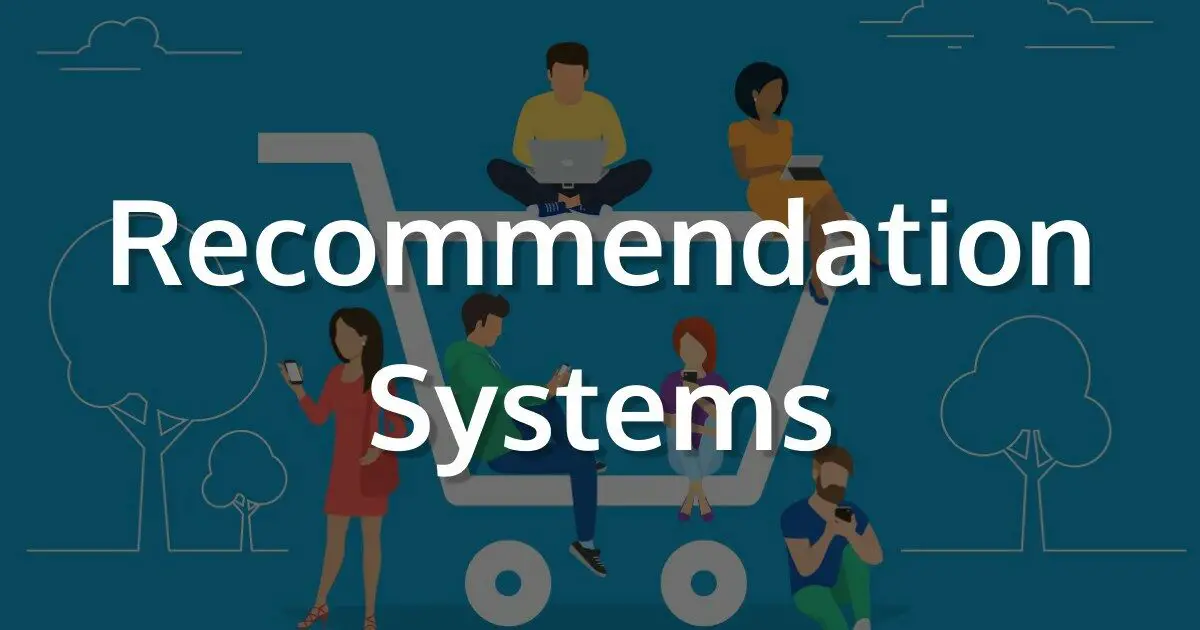

**Business Requirement:**“MyNextMovie” is a budding startup in the space of recommendations on top of various OTT platforms providing suggestions to its customer base regarding their next movie.Their  major  business  is  to  create  a  recommendation  layer  on  top  of  these  OTT  platformsso that they can make suitable recommendations to their customers,however, since they are in research  mode  right  now,  they  would  want  to  experiment  with  open-source data first to understand the depth of the models which can be delivered by them.<br>
The data for this exercise is open-source data thathas been collected and made available from the MovieLens website(http://movielens.org), a part of GroupLens<br>
Research The data sets were collected over various periods of time, depending on the size of the set.<br>
You have recently joined as a Data Scientist at “MyNextMovie” and plan to help the existing team to set up a recommendation platform.


In [ ]:
#importing libraries
import numpy as pd
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from scipy import sparse
import sklearn.metrics.pairwise as pw

cv = TfidfVectorizer()

In [ ]:
#Reading the data sets
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
print(movies.head(5))
print(ratings.head(5))

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
ratings.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
#Merging the two Data Sets
df = pd.merge(movies,ratings, how = "right",on="movieId")
df.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,3,Grumpier Old Men (1995),Comedy|Romance,1,4.0,964981247
2,6,Heat (1995),Action|Crime|Thriller,1,4.0,964982224
3,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1,5.0,964983815
4,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1,5.0,964982931


In [ ]:
#Finding the mean and count
data = df.groupby(['genres','title']).agg({'rating':['mean','count']})
data


rating      
                                                         mean count
genres             title                                           
(no genres listed) A Christmas Story Live! (2017)    2.000000     1
                   A Cosmic Christmas (1977)         4.000000     1
                   A Midsummer Night's Dream (2016)  4.000000     1
                   Ali Wong: Baby Cobra (2016)       4.500000     1
                   Ben-hur (2016)                    0.500000     1
...                                                       ...   ...
Western            True Grit (2010)                  3.750000    28
                   Wild Bill (1995)                  3.000000     4
                   Winchester '73 (1950)             4.000000     1
                   Winds of the Wasteland (1936)     3.500000     1
                   Wyatt Earp (1994)                 3.095238    21

[9724 rows x 2 columns]

In [ ]:
x = pd.merge(movies,data,how='left',on=(['genres','title']))
x = x.drop(['movieId'],axis = 1)
x.head(15)

<ipython-input-9-06fb21159d5a>:1: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (1 levels on the left,2 on the right)
  x = pd.merge(movies,data,how='left',on=(['genres','title']))


,title,genres,"(rating, mean)","(rating, count)"
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930,215.0
1,Jumanji (1995),Adventure|Children|Fantasy,3.431818,110.0
2,Grumpier Old Men (1995),Comedy|Romance,3.259615,52.0
3,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143,7.0
4,Father of the Bride Part II (1995),Comedy,3.071429,49.0
5,Heat (1995),Action|Crime|Thriller,3.946078,102.0
6,Sabrina (1995),Comedy|Romance,3.185185,54.0
7,Tom and Huck (1995),Adventure|Children,2.875000,8.0
8,Sudden Death (1995),Action,3.125000,16.0
9,GoldenEye (1995),Action|Adventure|Thriller,3.496212,132.0


In [ ]:
#Renaming
x.rename(columns = {('rating','count'):"Num Reviews",('rating','mean'):"Average Movie Rating","title":"Movie Title"},inplace = True)

**Objective:**<br>
**Part 1**<br>
1.Create a popularity-basedrecommender system at a genre level. The userwill input a genre (g), minimum ratingthreshold (t) for a movie,and no. ofrecommendations(N) for which it should be recommended top N movies which are most popular within that genre (g) ordered by ratings in descending order where each movie has at least (t) reviews.<br>
Example:Input:<br>
•Genre (g) : Comedy<br>
•Minimumreviewsthreshold(t):100<br>
•Num recommendations (N) : 5


In [ ]:
def recommendation(g,t,n):
  recommendation = x[(x["Num Reviews"]>=t)&(x["genres"]==g)].head(n)
  return(recommendation.drop(["genres"],axis = 1).head(5))

In [ ]:
g = input("Genre= ")
t = int(input("Minimum review threshold= "))
N = int(input("Num Recommendations= "))
recommendation(g,t,N)

Genre= Comedy
Minimum review threshold= 5
Num Recommendations= 100


,Movie Title,Average Movie Rating,Num Reviews
4,Father of the Bride Part II (1995),3.071429,49.0
17,Four Rooms (1995),3.700000,20.0
18,Ace Ventura: When Nature Calls (1995),2.727273,88.0
58,Bio-Dome (1996),2.532258,31.0
61,Friday (1995),3.775000,20.0


**2 Part** <br>
Create a content-based recommender system thatrecommends top N movies based on similar movie(m) genres.<br>
Example:Input:<br>
•Movie Title (t): Toy Story<br>
•Num recommendations (N): 5O


In [ ]:
tfidf_matrix = cv.fit_transform(movies['genres'])

In [ ]:
cosine_sim = linear_kernel(tfidf_matrix,tfidf_matrix)
print(cosine_sim)

[[1.         0.81357774 0.15276924 ... 0.         0.4210373  0.26758648]
 [0.81357774 1.         0.         ... 0.         0.         0.        ]
 [0.15276924 0.         1.         ... 0.         0.         0.57091541]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.4210373  0.         0.         ... 0.         1.         0.        ]
 [0.26758648 0.         0.57091541 ... 0.         0.         1.        ]]


In [ ]:
indices = pd.Series(movies.index,index=movies['title'])
indices

title
Toy Story (1995)                                0
Jumanji (1995)                                  1
Grumpier Old Men (1995)                         2
Waiting to Exhale (1995)                        3
Father of the Bride Part II (1995)              4
                                             ... 
Black Butler: Book of the Atlantic (2017)    9737
No Game No Life: Zero (2017)                 9738
Flint (2017)                                 9739
Bungo Stray Dogs: Dead Apple (2018)          9740
Andrew Dice Clay: Dice Rules (1991)          9741
Length: 9742, dtype: int64

In [ ]:
titles = movies['title']

In [ ]:
def recommendations(title,N):
  idx = indices[title]
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  sim_scores = sim_scores[1:N+1]
  movie_indices = [i[0] for i in sim_scores]
  return titles.iloc[movie_indices]


In [ ]:
t = input("Movie Title= ")
N = int(input("Num Recommendation= "))
recommendations(t,N)

Movie Title= Toy Story (1995)
Num Recommendation= 5


1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object

**Part 3**<br>
3.Create a collaborative based recommender system which recommends top N movies based on “K” similar users for a target user “u”<br>
Example:Input:<br>
•UserID:1<br>
•Num recommendations(N): 5•<br>
Threshold for similar users (k: 100)




In [ ]:
from scipy import sparse
import sklearn.metrics.pairwise as pw

def user_based_recom(input_dataframe,input_user_id):
  pivot_user_based = pd.pivot_table(input_dataframe, index='title', columns=['userId'], values='rating').T
  #print('pivot_user_based',pivot_user_based)
  sparse_pivot_ub = sparse.csr_matrix(pivot_user_based.fillna(0))
  #print('sparse_pivot_ub',sparse_pivot_ub)
  user_recomm = pw.cosine_similarity(sparse_pivot_ub)
  user_recomm_df = pd.DataFrame(user_recomm, columns = pivot_user_based.index.values, index=pivot_user_based.index.values)
  #print('user_recomm_df',user_recomm_df)
  ## Item Rating based Cosine Similarity
  usr_cosine_df = pd.DataFrame(user_recomm_df[input_user_id].sort_values(ascending=False))
  usr_cosine_df.reset_index(level=0,inplace=True)
  usr_cosine_df.columns = ['userId','cosine_sim']
  return usr_cosine_df

In [ ]:
df=pd.merge(ratings,movies, how='right',on='movieId')
data=df.groupby(["genres","title"]).agg({"rating":['mean','count']})
x= pd.merge(data,movies, how='left',on=(["genres",'title']))
x.rename(columns={('rating', 'count'):"Num Reviews",('rating', 'mean'):"Average Movie Rating","title":"Movie Title" },inplace=True)


<ipython-input-47-54fae499cce1>:3: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left,1 on the right)
  x= pd.merge(data,movies, how='left',on=(["genres",'title']))


In [ ]:
y=pd.merge(x,ratings, how='right',on=(["movieId"]))
y.columns
y=y.drop(['genres','rating', 'timestamp'],axis=1)

In [ ]:
y.head()

,Movie Title,Average Movie Rating,Num Reviews,movieId,userId
0,Toy Story (1995),3.920930,215,1,1
1,Grumpier Old Men (1995),3.259615,52,3,1
2,Heat (1995),3.946078,102,6,1
3,Seven (a.k.a. Se7en) (1995),3.975369,203,47,1
4,"Usual Suspects, The (1995)",4.237745,204,50,1


In [ ]:
def user_rec(u,n,k):
    z=user_based_recom(df,u)
    z=z.drop(0).head()
    index=['Movie Title']
    new_df= pd.DataFrame(columns=index)
    new_df=new_df.drop(["Movie Title"],axis=1)
    #print('new_df',new_df)
    for j in range(n):
        for i in z["userId"]:
            temp=(y[(y["userId"]==i) & (y["Num Reviews"]>=k)]).head(j)
            new_df= pd.concat([new_df,temp["Movie Title"]],axis=0)
    new_df.rename(columns={0:"Movie Title"},inplace=True)
    new_df=new_df.drop_duplicates(["Movie Title"]).head(n)
    return new_df

In [ ]:
u= int(input("Enter UserId= "))
N=int(input("Number of Recommendations= "))
k= int(input("Enter Threshold for similar u5sers= "))
user_rec(u,N,k)


Enter UserId= 1
Number of Recommendations= 5
Enter Threshold for similar u5sers= 100


,Movie Title
38665,Toy Story (1995)
48241,Heat (1995)
48242,GoldenEye (1995)
14122,Jumanji (1995)
38671,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
